# Analyzing Age Discrimination in a Recommendation System

## Introduction

In this exercise, we will examine a content recommendation system for potential age bias. We'll use a simple collaborative filtering model and analyze its recommendations across different age groups.

In [ ]:
!pip install pandas numpy scipy scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore TypedStorage is deprecated
warnings.filterwarnings('ignore', category=FutureWarning)

## Step 1: Create a Synthetic Dataset

We'll create a synthetic dataset of user ratings for different content items, with stronger age-based preferences.

In [2]:
np.random.seed(42)
n_users = 1000
n_items = 50

# Create user data
users = pd.DataFrame({
    'user_id': range(n_users),
    'age': np.random.randint(18, 80, n_users)
})

# Create item data
items = pd.DataFrame({
    'item_id': range(n_items),
    'category': np.random.choice(['A', 'B', 'C', 'D'], n_items)
})

# Create ratings data with stronger age-based preferences
ratings = []
for user in users['user_id']:
    n_ratings = np.random.randint(5, 20)
    rated_items = np.random.choice(items['item_id'], n_ratings, replace=False)
    for item in rated_items:
        if users.loc[user, 'age'] > 50 and items.loc[item, 'category'] in ['C', 'D']:
            rating = np.random.randint(4, 6)  # Higher ratings for older users
        elif users.loc[user, 'age'] < 30 and items.loc[item, 'category'] in ['A', 'B']:
            rating = np.random.randint(4, 6)  # Higher ratings for younger users
        else:
            rating = np.random.randint(1, 4)  # Lower ratings for other cases
        ratings.append({'user_id': user, 'item_id': item, 'rating': rating})

ratings = pd.DataFrame(ratings)

print("Users:", users.shape)
print("Items:", items.shape)
print("Ratings:", ratings.shape)
print(ratings.head())

Users: (1000, 2)
Items: (50, 2)
Ratings: (12104, 3)
   user_id  item_id  rating
0        0       15       2
1        0       34       4
2        0       12       2
3        0        8       1
4        0       37       2


## Step 2: Analyze Initial Data Distribution

Initial preferences by age group:
category          A         B         C         D
age_group                                        
Young      4.348723  4.324786  2.029795  2.064935
Middle     1.987730  1.989515  1.997783  2.000000
Senior     1.999288  2.011054  4.521555  4.505785


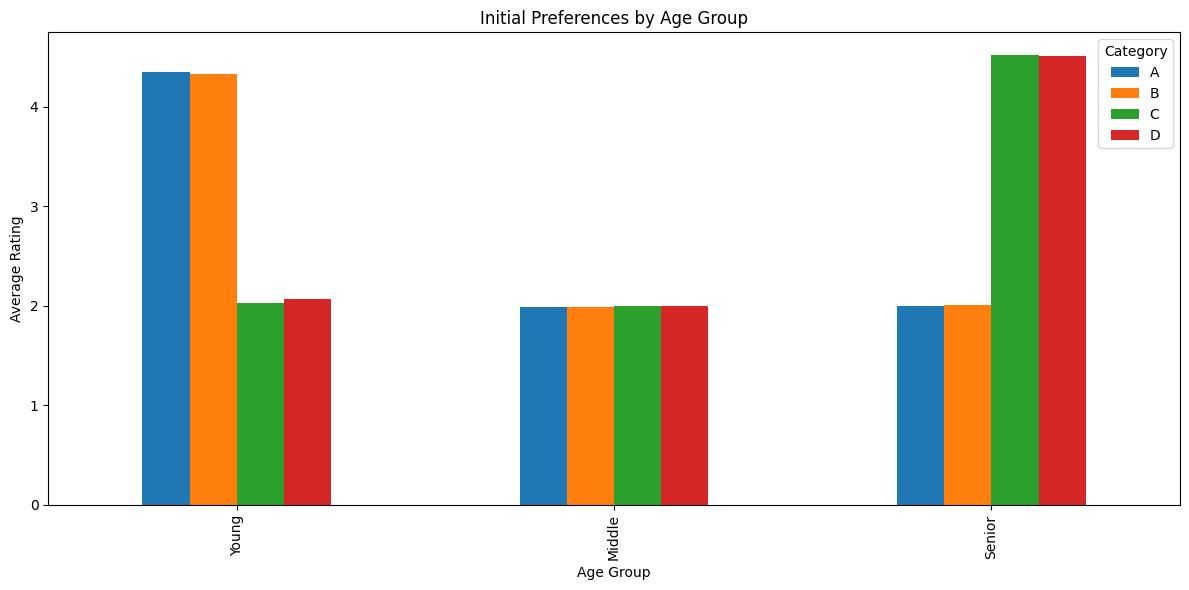

In [3]:
def analyze_preferences(ratings_data, users_data, items_data):
    merged_data = ratings_data.merge(users_data, on='user_id').merge(items_data, on='item_id')
    merged_data['age_group'] = pd.cut(merged_data['age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])
    
    preferences = merged_data.groupby(['age_group', 'category'])['rating'].mean().unstack()
    return preferences

initial_preferences = analyze_preferences(ratings, users, items)
print("Initial preferences by age group:")
print(initial_preferences)

# Visualize initial preferences
initial_preferences.plot(kind='bar', figsize=(12, 6))
plt.title('Initial Preferences by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Rating')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

## Step 3: Prepare Data for Collaborative Filtering

In [4]:
# Create a user-item matrix
user_item_matrix = ratings.pivot(index='user_id', columns='item_id', values='rating').fillna(0)

# Create a sparse matrix
user_item_matrix_sparse = csr_matrix(user_item_matrix.values)

print("User-Item Matrix Shape:", user_item_matrix.shape)

User-Item Matrix Shape: (1000, 50)


## Step 4: Build and Train the Recommendation Model

In [5]:
# Initialize the model
model_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20, n_jobs=-1)

# Fit the model
model_knn.fit(user_item_matrix_sparse)

print("Model trained successfully.")

Model trained successfully.


## Step 5: Generate Recommendations

In [6]:
def get_recommendations(user_id, n_recommendations=5):
    user_vector = user_item_matrix_sparse[user_id]
    _, indices = model_knn.kneighbors(user_vector, n_neighbors=n_recommendations+1)
    similar_users = indices.flatten()[1:]
    
    # Get items that the user hasn't rated
    user_rated_items = set(ratings[ratings['user_id'] == user_id]['item_id'])
    all_items = set(range(n_items))
    items_to_recommend = list(all_items - user_rated_items)
    
    # Calculate average ratings for these items from similar users
    item_scores = []
    for item in items_to_recommend:
        item_ratings = ratings[(ratings['user_id'].isin(similar_users)) & (ratings['item_id'] == item)]['rating']
        if len(item_ratings) > 0:
            item_scores.append((item, item_ratings.mean()))
    
    # Sort and return top N recommendations
    item_scores.sort(key=lambda x: x[1], reverse=True)
    return [item for item, score in item_scores[:n_recommendations]]

# Generate recommendations for all users
all_recommendations = {user: get_recommendations(user) for user in users['user_id']}

print("Recommendations generated for all users.")
print("Sample recommendations for user 0:", all_recommendations[0])

Recommendations generated for all users.
Sample recommendations for user 0: [7, 21, 30, 46, 9]


## Step 6: Analyze Recommendations Across Age Groups

In [7]:
def analyze_recommendations(recommendations, users, items):
    results = []
    for user, recs in recommendations.items():
        user_age = users.loc[user, 'age']
        age_group = 'Young' if user_age < 30 else 'Middle' if user_age < 50 else 'Senior'
        rec_categories = items.loc[recs, 'category'].value_counts().to_dict()
        results.append({
            'user_id': user,
            'age': user_age,
            'age_group': age_group,
            'A': rec_categories.get('A', 0),
            'B': rec_categories.get('B', 0),
            'C': rec_categories.get('C', 0),
            'D': rec_categories.get('D', 0)
        })
    return pd.DataFrame(results)

recommendation_analysis = analyze_recommendations(all_recommendations, users, items)

# Calculate average recommendations per category for each age group
age_group_analysis = recommendation_analysis.groupby('age_group')[['A', 'B', 'C', 'D']].mean()
print("Average recommendations by age group:")
print(age_group_analysis)

Average recommendations by age group:
                  A         B         C         D
age_group                                        
Middle     1.909968  0.919614  1.504823  0.665595
Senior     0.628180  0.318982  2.953033  1.099804
Young      3.117978  1.314607  0.443820  0.123596


## Step 7: Visualize the Results

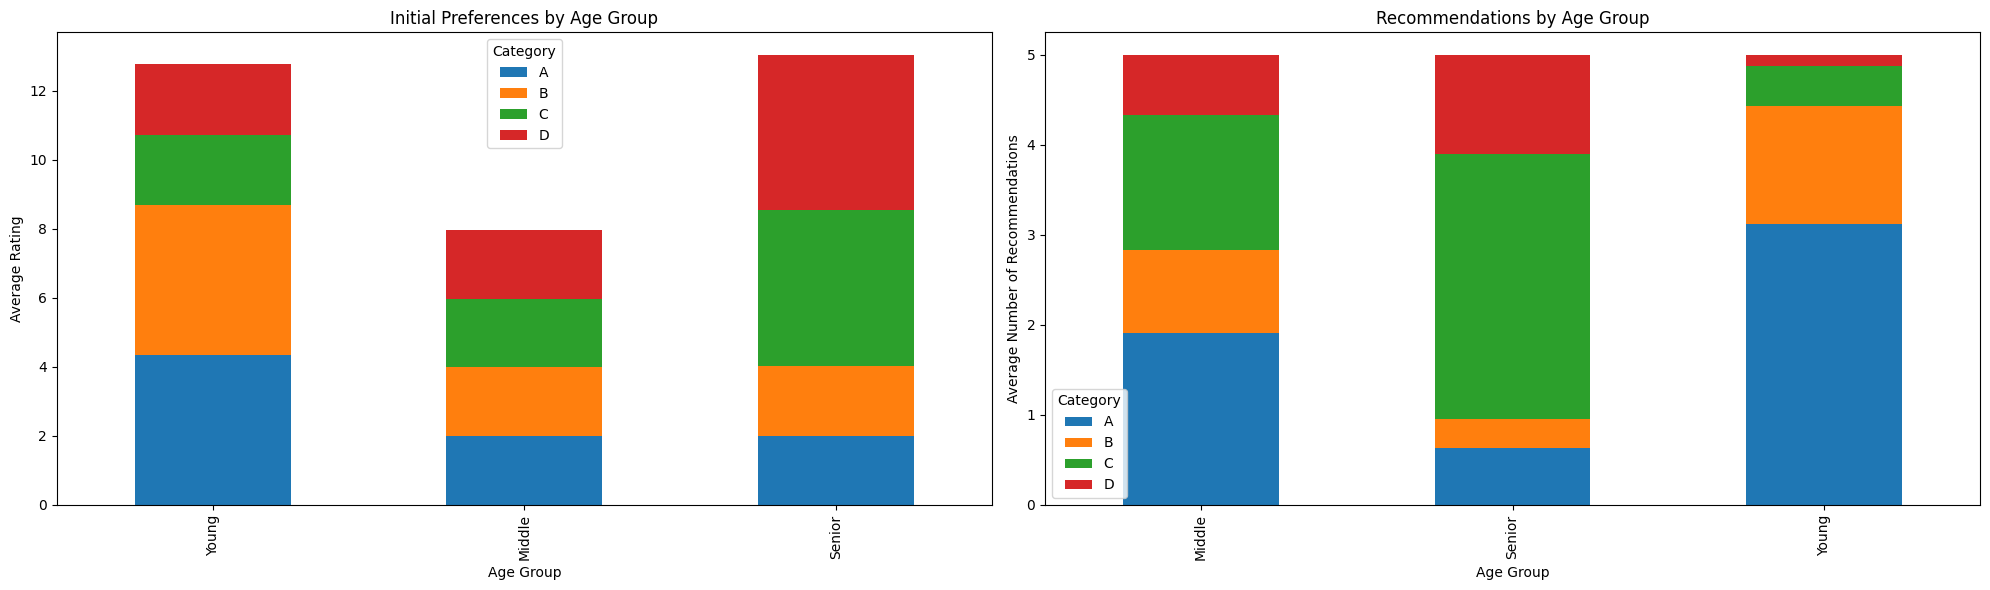

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

initial_preferences.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_title('Initial Preferences by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Rating')
ax1.legend(title='Category')

age_group_analysis.plot(kind='bar', stacked=True, ax=ax2)
ax2.set_title('Recommendations by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average Number of Recommendations')
ax2.legend(title='Category')

plt.tight_layout()
plt.show()

## Step 8: Compare Initial Preferences with Recommendations

Difference between recommendations and initial preferences:
                  A         B         C         D
age_group                                        
Middle    -0.077762 -1.069901 -0.492960 -1.334405
Senior    -1.371108 -1.692072 -1.568522 -3.405981
Young     -1.230745 -3.010180 -1.585975 -1.941340


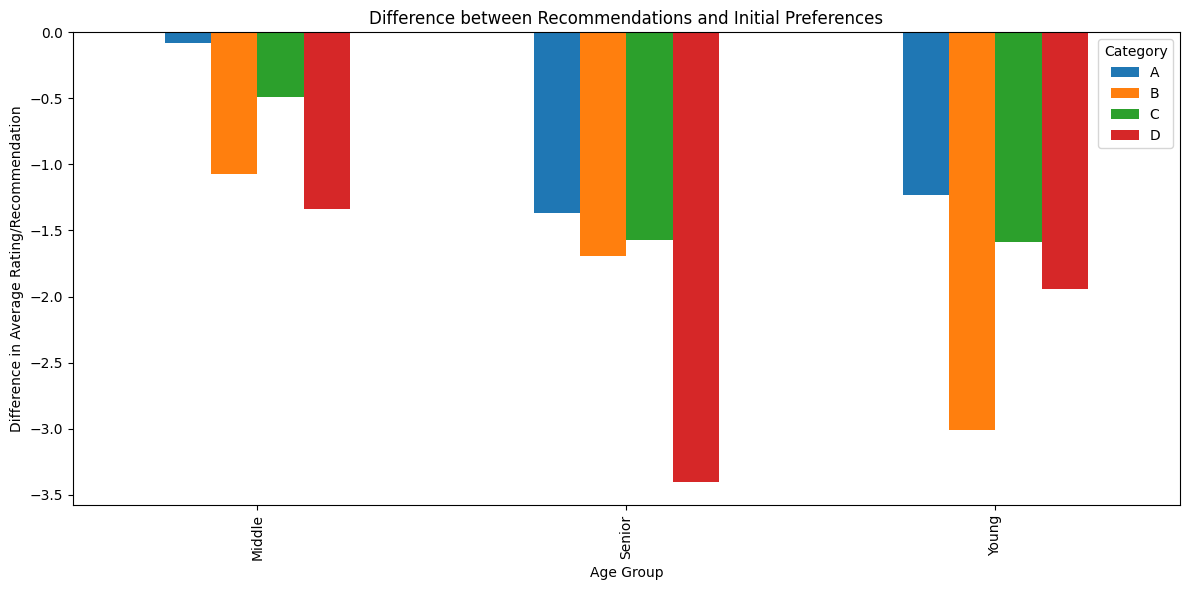

In [9]:
print("Difference between recommendations and initial preferences:")
print(age_group_analysis - initial_preferences)

# Visualize the difference
difference = age_group_analysis - initial_preferences
difference.plot(kind='bar', figsize=(12, 6))
plt.title('Difference between Recommendations and Initial Preferences')
plt.xlabel('Age Group')
plt.ylabel('Difference in Average Rating/Recommendation')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

## Step 9: Analyze the Results

Based on the visualization and data, answer the following questions:

1. Are there noticeable differences in recommendation patterns across age groups?

Yes. Young users receive mostly A/B category recommendations, Senior users receive mostly C/D, and Middle-aged users get a more mixed but A-heavy distribution — closely mirroring the synthetic bias built into the dataset.

2. Which categories seem to be recommended more often to specific age groups?

Young -> Categories A & B
Senior -> Categories C & D
Middle -> Category A dominates, others are low

3. How do the recommendations compare to the initial preferences? Are biases being amplified or reduced?

The difference table shows all values are negative, meaning recommendations fall short of initial preferences for every group/category. However, young still gets more A/B, senior more C/D, so bias is reproduced but slightly attenuated — not amplified, not corrected.

4. Do you think these differences reflect genuine preferences or potential age bias?

The dataset was synthetically constructed with age-based rating boosts, so the model learned a real signal — but that signal encodes demographic stereotyping

5. How might these recommendation patterns impact users' experiences with the platform?

Users are effectively siloed into age-defined content bubbles. Senior users rarely see A/B content; Young users rarely see C/D. Over time this reduces content diversity and reinforces assumptions about what users "should" want based on age.

## Step 10: Propose Mitigation Strategies

Based on your analysis, suggest some strategies to mitigate the observed age-related differences in recommendations. Consider the following approaches:

1. Adjusting the collaborative filtering algorithm to reduce age-based similarities
2. Implementing a hybrid recommendation system that combines collaborative and content-based filtering
3. Introducing diversity constraints in the recommendation generation process
4. Developing separate models for different age groups

Choose one of these strategies and describe how you would implement it in this context.

In [10]:
# Diversity constraints in recommendation generation
## post-process recommendations to enforce category balance
def get_diverse_recommendations(user_id, n_recommendations=5, max_per_category=2):
    user_vector = user_item_matrix_sparse[user_id]
    _, indices = model_knn.kneighbors(user_vector, n_neighbors=n_recommendations + 1)
    similar_users = indices.flatten()[1:]

    user_rated_items = set(ratings[ratings['user_id'] == user_id]['item_id'])
    items_to_recommend = list(set(range(n_items)) - user_rated_items)

    item_scores = []
    for item in items_to_recommend:
        item_ratings = ratings[
            (ratings['user_id'].isin(similar_users)) & (ratings['item_id'] == item)
        ]['rating']
        if len(item_ratings) > 0:
            item_scores.append((item, item_ratings.mean(), items.loc[item, 'category']))

    item_scores.sort(key=lambda x: x[1], reverse=True)

    # Enforce category cap
    category_counts = {cat: 0 for cat in ['A', 'B', 'C', 'D']}
    diverse_recs = []
    for item, score, category in item_scores:
        if category_counts[category] < max_per_category:
            diverse_recs.append(item)
            category_counts[category] += 1
        if len(diverse_recs) == n_recommendations:
            break

    return diverse_recs

diverse_recommendations = {
    user: get_diverse_recommendations(user) for user in users['user_id']
}
diverse_analysis = analyze_recommendations(diverse_recommendations, users, items)
diverse_age_group = diverse_analysis.groupby('age_group')[['A', 'B', 'C', 'D']].mean()
print("Diverse recommendations by age group:")
print(diverse_age_group)

Diverse recommendations by age group:
                  A         B         C         D
age_group                                        
Middle     1.627010  1.099678  1.459807  0.813505
Senior     1.240705  0.645793  1.855186  1.258317
Young      1.955056  1.640449  1.039326  0.365169


Senior users saw the largest improvement — category A went from 0.63 -> 1.24 and B from 0.32 -> 0.65, while C was reduced from 2.95 -> 1.86. The group is now exposed to content it was previously almost never shown.

Young users still receive more A/B content but C went from 0.44 -> 1.04 , a meaningful cross-category exposure boost.
the gap is substantially narrowed. The system now reflects a soft preference rather than a hard.

## Step 11: Reflection and Discussion

Reflect on the following questions:

1. What are the ethical implications of age-biased recommendations in content platforms?

Age-biased recommendations can reinforce stereotypes, limit content diversity, and contribute to social isolation by creating echo chambers. They may also lead to unequal access to information and opportunities, particularly for older users who may be marginalized in digital spaces.

2. How might age bias in recommendations contribute to filter bubbles or echo chambers?

When users only receive age-segmented content, they are less likely to encounter ideas, styles, or perspectives from other generations. This deepens intergenerational divides and reduces the shared cultural commons that enables cross-age dialogue.

3. What are the challenges in balancing personalization with the need for diverse content exposure across age groups?

Pure personalization optimizes for engagement (clicks, watch time) which naturally exploits existing preferences. Introducing diversity reduces short-term engagement metrics, making it hard to justify to stakeholders. The challenge is defining fairness constraints without destroying utility — a multi-objective optimization problem with no single "correct" answer.

4. How can recommendation systems be designed to promote intergenerational understanding and connection?

- We should strt with include similarity scores across age groups, not just within them.
- Identify items popular across multiple age groups and boost their visibility

- Let users actively choose to see what other age groups enjoy


## Bonus Tasks

1. Implement one of the mitigation strategies you proposed and analyze its impact on age-related differences in recommendations.
2. Explore how other demographic factors (e.g., gender, location) might intersect with age in influencing recommendations.
3. Research real-world examples of age bias in recommendation systems and compare them to your findings.
4. Discuss the potential societal impacts of age-biased recommendation systems in various domains (e.g., news, entertainment, education).

# please put your answer here